# [Python Reference Link](http://www.data8.org/sp20/python-reference.html)
*Run the cell below so that we can set our modules up*# Importing our modules

In [ ]:
import numpy as np
from datascience import *
import math as m

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [ ]:
births = Table.read_table('baby.csv')
births

# Mean vs. Median

#### Calculating the mean and the median

In [ ]:
sample_data = make_array(2,3,3,9)
print('sample data:',sample_data)
print('mean/average:',np.mean(sample_data))
print('median:',np.median(sample_data))

#### Visualizing the concept of the mean acting as the 'Center of Gravity

In [ ]:
Table().with_column('Sample Data', sample_data).hist(bins=np.arange(0,10,1))
plt.ylim(-0.04,0.5)
plt.plot([0,10],[0,0],color='grey',lw=2)
plt.scatter(np.mean(sample_data),-0.015,marker='^',color='red',s=100)
plt.title('Average as a "Center of Gravity"')

#### A histogram of a Symmetric Distribution (more specifically, a Normal Distribution; Bell-Shaped Curve)

In [ ]:
weight_bins = np.arange(50,180,10)
births.hist("Birth Weight",bins=weight_bins)

#### A Histogram of a Right-Skewed Distribution

In [ ]:
input_values = np.arange(0,15,0.1)
exponential_curve = 0.25*m.e**(0.25*input_values)

r_skew_bins = np.arange(0,12,1)
Table().with_columns('values',exponential_curve).hist(bins=r_skew_bins)

#### A Histogram of a Left-Skewed Distribution

In [ ]:
reverse_exponential = 130 - exponential_curve

l_skew_bins = np.arange(118,130,1)
Table().with_columns('others',reverse_exponential).hist(bins = l_skew_bins)

## Let's look at the relationship between the Mean and the Median between these different distribution types

In [ ]:
births.hist("Birth Weight",bins=weight_bins)
plt.scatter(np.mean(births.column('Birth Weight')), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(births.column('Birth Weight')), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.001, 0.03); 

In [ ]:
Table().with_columns('values',exponential_curve).hist(bins=r_skew_bins)
plt.scatter(np.mean(exponential_curve), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(exponential_curve), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.005, 0.37);

In [ ]:
Table().with_columns('others',reverse_exponential).hist(bins = l_skew_bins)
plt.scatter(np.mean(reverse_exponential), 0, color='red', zorder=2, s=50, label="Mean")
plt.scatter(np.median(reverse_exponential), 0, color='blue', zorder=2, s=50, label="Median")
plt.legend()
plt.ylim(-0.005, 0.37);

# Quantifying Variability i.e. Standard Deviation

In [ ]:
#since we are computing a formula, we will use some methods from the math module
import math as m

In [ ]:
birth_weights = births.column('Birth Weight')
print('mean:',np.mean(birth_weights))
print('birth weights:',birth_weights)

### Root Mean Square of "***Deviations from Average***"
We first want to measure the deviations from average (i.e. look at how far away each data point is from the mean/average)

In [ ]:
deviations = ...
deviations_table = Table().with_columns('Birth Weights',birth_weights,
                                       'Average',np.ones(len(birth_weights))*np.mean(birth_weights),
                                       'Deviations', deviations)
deviations_table.show(10)
print('Here is the array of deviations:')
deviations

### Root Mean "***Square***" of Deviations from Average
An effort to turn all the values positive by squaring each deviation from average

In [ ]:
square_deviations = ...
square_deviations

### Root "***Mean***" Square of Deviations from Average
Now we compute the mean/average of the square deviations from above

In [ ]:
mean_square_deviations = ...

### "***Root***" Mean Square of Deviations from Average
Since we squared the deviations above, we are going to undo that by taking the square root. 

In [ ]:
root_mean_square_deviations = ...

In [ ]:
np.std(birth_weights)

# Reflection Response: 
Let’s watch this video of Hannah Fry, explaining the relationship between the mathematics (probability theory) and crime & terrorism

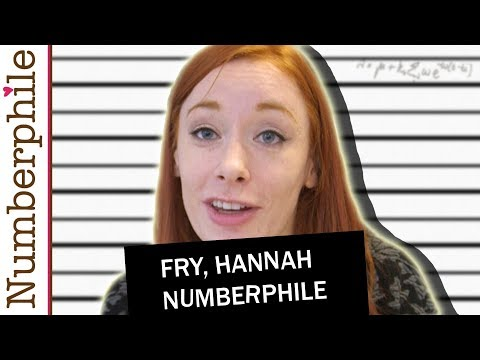

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('lCjspXB5F4A', width=800, height=300)

# Examining the Central Limit Theorem - The Distribution of Averages

### When the underlying Distribution is Symmetric 

In [ ]:
births.drop(5).hist(overlay=False)

In [ ]:
#Let's look at a few columns in the births table 
sample_size = 100
number_of_resamples = 1000
column_name = "Birth Weight"

means = make_array()

for i in np.arange(number_of_resamples):
    one_small_sample = births.sample(sample_size,with_replacement=True)
    mean_of_one_small_sample = np.mean(one_small_sample.column(column_name))
    means = np.append(means, mean_of_one_small_sample)

Table().with_columns('Means of'+column_name,means).hist()

### When the underlying Distribution is Right-Skewed

In [ ]:
input_values = np.arange(0,15,0.1)
exponential_curve = 0.25*m.e**(0.25*input_values)

r_skew_bins = np.arange(0,12,1)
r_skew_table = Table().with_columns('values',exponential_curve)
r_skew_table.hist(bins=r_skew_bins)

In [ ]:
# Let's look at sampling from a right skew distribution
sample_size = 100
number_of_resamples = 1000

means = make_array()

for i in np.arange(number_of_resamples):
    one_small_sample = r_skew_table.sample(sample_size,with_replacement=True)
    mean_of_one_small_sample = np.mean(one_small_sample.column('values'))
    means = np.append(means, mean_of_one_small_sample)

Table().with_columns('Means',means).hist() 

### When the underlying Distribution is Left-Skewed

In [ ]:
reverse_exponential = 130 - exponential_curve

l_skew_bins = np.arange(118,130,1)
l_skew_table = Table().with_columns('values',reverse_exponential)
l_skew_table.hist(bins = l_skew_bins)

In [ ]:
# Let's look at sampling from a left skew distribution
sample_size = 100
number_of_resamples = 1000

means = make_array()

for i in np.arange(number_of_resamples):
    one_small_sample = l_skew_table.sample(sample_size,with_replacement=True)
    mean_of_one_small_sample = np.mean(one_small_sample.column('values'))
    means = np.append(means, mean_of_one_small_sample)

Table().with_columns('Means',means).hist()  

## Manipulating Sample Size and Number of Resamples

In [ ]:
#Let's look at a few columns in the births table, but now with increased sample size
sample_size = 1000
number_of_resamples = 1000
column_name = "Birth Weight"

means = make_array()

for i in np.arange(number_of_resamples):
    one_small_sample = births.sample(sample_size,with_replacement=True)
    mean_of_one_small_sample = np.mean(one_small_sample.column(column_name))
    means = np.append(means, mean_of_one_small_sample)

Table().with_columns('Means of'+column_name,means).hist()  

In [ ]:
#Let's look at a few columns in the births table, but now with increased number of resamples
sample_size = 100
number_of_resamples = 10000
column_name = "Birth Weight"

means = make_array()

for i in np.arange(number_of_resamples):
    one_small_sample = births.sample(sample_size,with_replacement=True)
    mean_of_one_small_sample = np.mean(one_small_sample.column(column_name))
    means = np.append(means, mean_of_one_small_sample)

Table().with_columns('Means of '+column_name,means).hist()